In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving archive (6).zip to archive (6).zip


In [5]:
import zipfile
import os

# Unzip the uploaded archive
zip_file_path = '/content/archive (6).zip'
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Define the base path where the CSVs are located inside the unzipped directory
base_path = '/content/banking_dataset_kaggle/data/csv/'

customers = pd.read_csv(os.path.join(base_path, "customers.csv"))
accounts = pd.read_csv(os.path.join(base_path, "accounts.csv"))
loans = pd.read_csv(os.path.join(base_path, "loans.csv"))
cards = pd.read_csv(os.path.join(base_path, "cards.csv"))
branches = pd.read_csv(os.path.join(base_path, "branches.csv"))
merchants = pd.read_csv(os.path.join(base_path, "merchants.csv"))

In [6]:
customers.head()
customers.tail()
customers.sample(5)

customers.shape
accounts.shape
loans.shape
cards.shape

customers.columns
accounts.columns

customers.info()
accounts.info()

customers.describe()
accounts.describe()

customers.dtypes
accounts.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   customer_id   50000 non-null  object
 1   first_name    50000 non-null  object
 2   last_name     50000 non-null  object
 3   email         50000 non-null  object
 4   city          50000 non-null  object
 5   credit_score  50000 non-null  int64 
 6   created_at    50000 non-null  object
dtypes: int64(1), object(6)
memory usage: 2.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   account_id    75000 non-null  object 
 1   customer_id   75000 non-null  object 
 2   account_type  75000 non-null  object 
 3   balance_usd   75000 non-null  float64
 4   open_date     75000 non-null  object 
dtypes: float64(1), object(4)
memory usage: 2.9+ MB


,0
account_id,object
customer_id,object
account_type,object
balance_usd,float64
open_date,object


In [7]:
customers.isnull().sum()

accounts.isnull().sum()

loans.isnull().sum()

cards.isnull().sum()

customers.isnull().mean()*100

accounts.isnull().mean()*100

customers.dropna()

accounts.fillna(0)

customers.duplicated().sum()

accounts.duplicated().sum()

np.int64(0)

In [8]:
customers['credit_score'].mean()

customers['credit_score'].median()

customers['credit_score'].mode()

customers['credit_score'].std()

customers['credit_score'].min()

customers['credit_score'].max()

accounts['balance_usd'].sum()

accounts['balance_usd'].mean()

accounts['balance_usd'].median()

accounts['balance_usd'].max()

accounts['balance_usd'].min()

loans['loan_amount'].sum()

loans['loan_amount'].mean()

loans['loan_amount'].max()

loans['loan_amount'].min()

1010.16

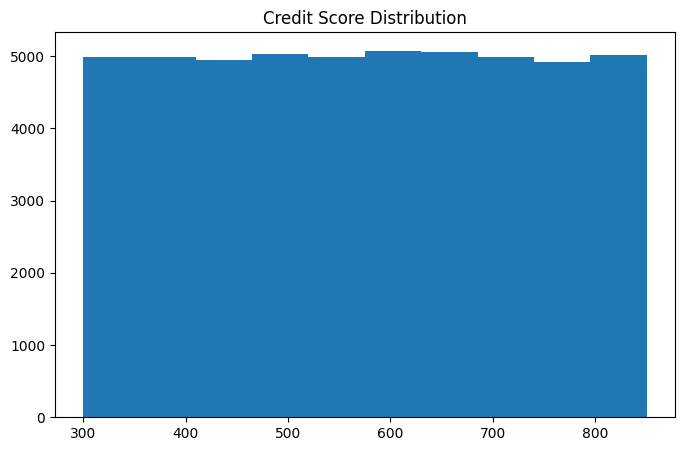

In [9]:
plt.figure(figsize=(8,5))
plt.hist(customers['credit_score'])
plt.title("Credit Score Distribution")
plt.show()

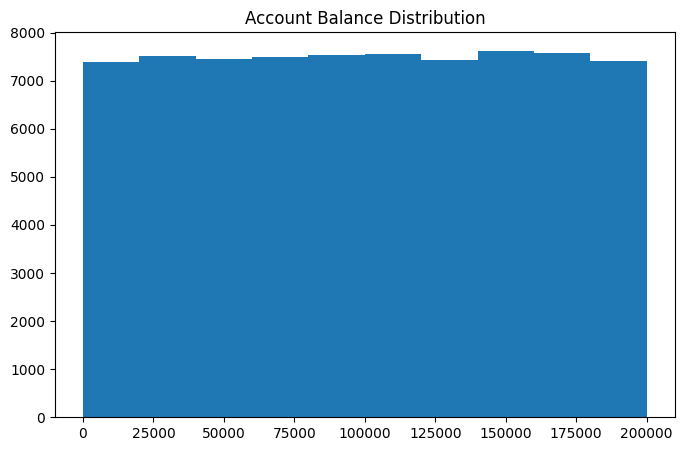

In [10]:
plt.figure(figsize=(8,5))
plt.hist(accounts['balance_usd'])
plt.title("Account Balance Distribution")
plt.show()

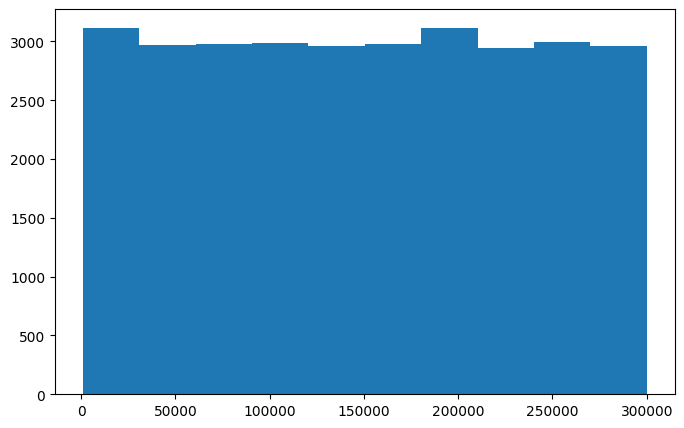

In [11]:
plt.figure(figsize=(8,5))
plt.hist(loans['loan_amount'])
plt.show()

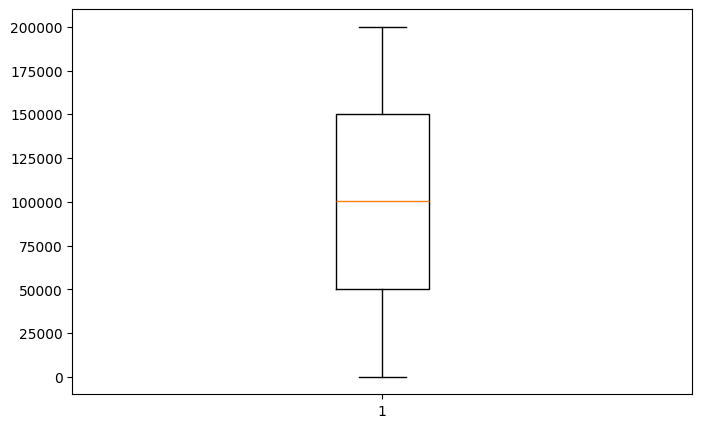

In [12]:
plt.figure(figsize=(8,5))
plt.boxplot(accounts['balance_usd'])
plt.show()

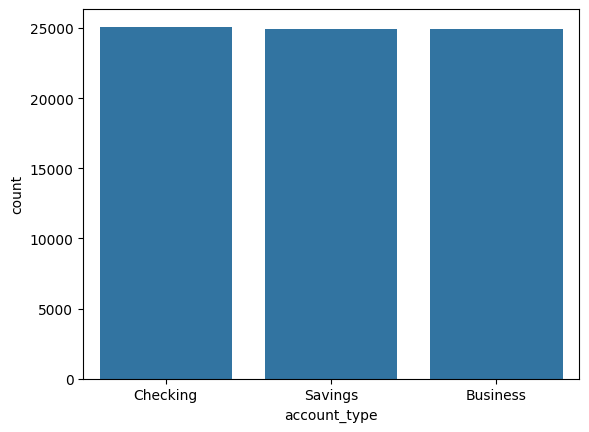

In [13]:
sns.countplot(data=accounts,
              x='account_type')
plt.show()

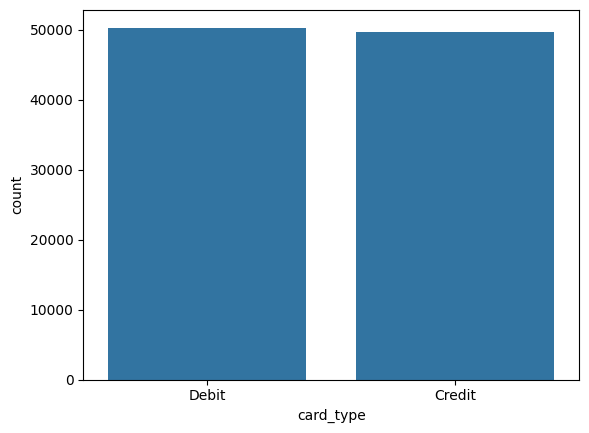

In [14]:
sns.countplot(data=cards,
              x='card_type')
plt.show()

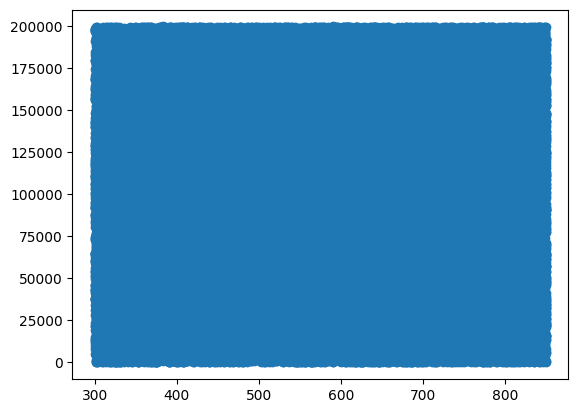

In [15]:
merged = customers.merge(accounts,
                         on='customer_id')

plt.scatter(merged['credit_score'],
            merged['balance_usd'])

plt.show()

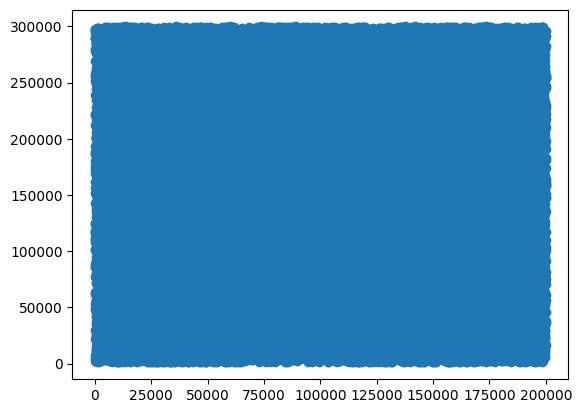

In [16]:
merged = accounts.merge(loans,
                        on='customer_id')

plt.scatter(merged['balance_usd'],
            merged['loan_amount'])

plt.show()

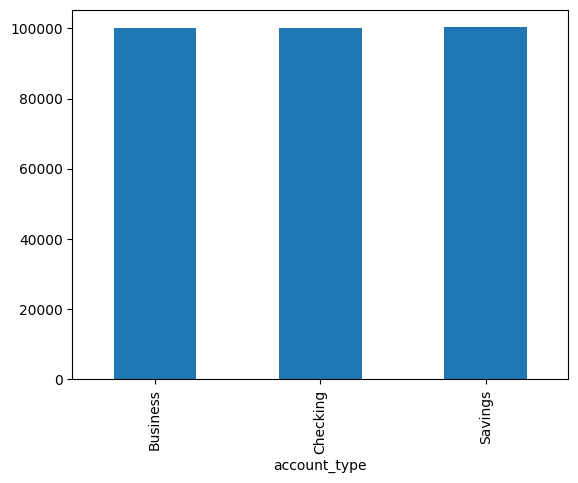

In [17]:
accounts.groupby("account_type")["balance_usd"].mean().plot(kind='bar')

plt.show()

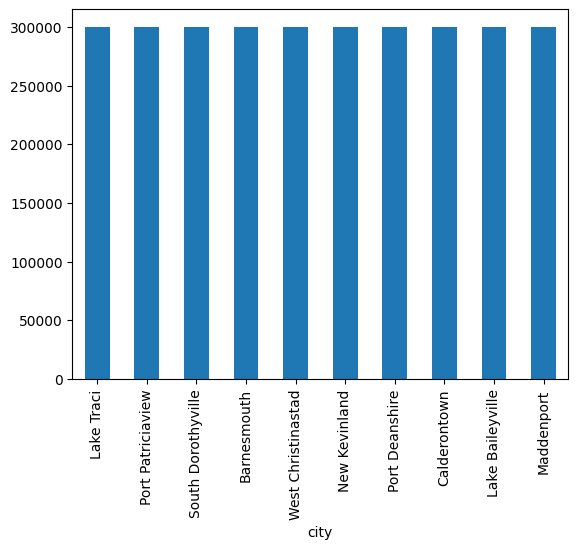

In [18]:
merged = customers.merge(loans,
                         on='customer_id')

merged.groupby("city")["loan_amount"].mean().sort_values().tail(10).plot(kind='bar')

plt.show()

In [19]:
merged = customers.merge(accounts,
                         on='customer_id')

merged.corr(numeric_only=True)

,credit_score,balance_usd
credit_score,1.000000,-0.004153
balance_usd,-0.004153,1.000000


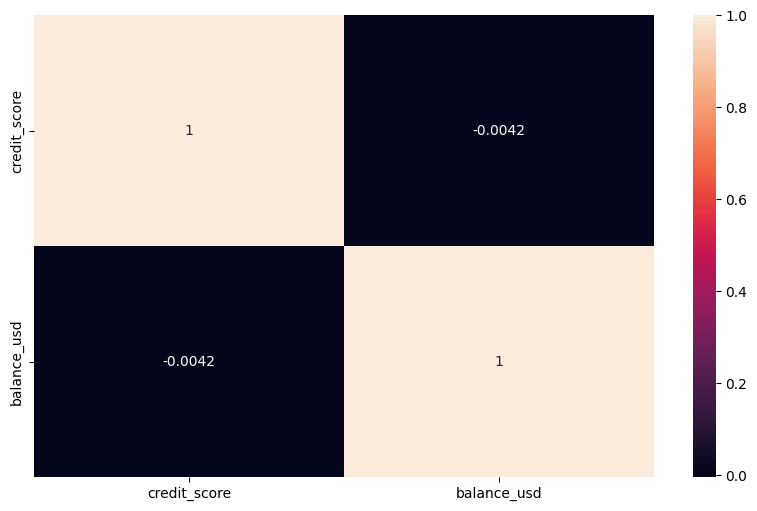

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(
    merged.corr(numeric_only=True),
    annot=True
)

plt.show()

In [21]:
accounts.nlargest(10,
                  "balance_usd")

,account_id,customer_id,account_type,balance_usd,open_date
60271,ACCYWA9TSM1GXTG,CUSEXB4Z7J8HWE2,Checking,199994.58,2022-08-26
16167,ACC5HOPZOH2VAZX,CUS05F95VDL5G26,Savings,199989.26,2021-09-07
37941,ACCSRWHMGDL92R2,CUSTCFNYEBCRW2Y,Business,199969.50,2019-09-28
2067,ACCKNEQVI7LDS4Y,CUSFSEINJWX8QJ5,Business,199968.62,2022-11-05
72557,ACC92CJD3LIRR0X,CUSXKDR73U5XXC8,Business,199965.37,2024-08-15
15102,ACCNUR2OMRJAFA2,CUSI7GKRTQLXK5F,Savings,199963.49,2020-06-23
19640,ACC3HQFDY5BQ3TV,CUSXKXUPNM6VUWR,Savings,199963.38,2022-11-02
24261,ACC31UVSUZFS8QX,CUSVMJB7L3FQ5AX,Checking,199961.03,2024-12-08
68528,ACCD0TU30OTVMXU,CUSLGUPUOWOB7P7,Business,199958.24,2019-07-19
855,ACCODRZK7G0T999,CUSSKZH0SZOHX2H,Savings,199956.88,2023-06-25


In [22]:
accounts.nsmallest(10,
                   "balance_usd")

,account_id,customer_id,account_type,balance_usd,open_date
15200,ACC3L52RG32PLC1,CUS27D326TP8SFA,Business,13.20,2020-04-19
7704,ACCF0FF84LB8V6V,CUSHQQESGMMT2GL,Savings,13.21,2021-12-13
26283,ACCQY6YF7WP27BP,CUSM21QSNKM1LDM,Business,26.44,2023-01-10
16374,ACCOW22KWAQFDR1,CUSXZ5IST4T86UZ,Business,27.59,2020-11-01
66653,ACCZQ47R2J49PDP,CUSWJRLKU8F1OP9,Checking,28.55,2025-11-29
26756,ACCL76VCMT4Y0HZ,CUS4W6OZX25QBRM,Savings,35.49,2019-07-20
63041,ACC2SQHSZRLOAO4,CUS1CD0DQ5621WJ,Savings,39.51,2024-08-26
37517,ACCBKYLNQJRX1F4,CUS1TXQ4JGDKJ6O,Checking,41.56,2024-01-17
49359,ACC0GD3IYX22B07,CUSQ4JMRDI8S9IC,Savings,44.27,2023-11-08
16387,ACCCRXK9IGJ68MI,CUSR0P5UNM3ZAQS,Checking,46.17,2025-02-21


In [23]:
loans.nlargest(10,
               "loan_amount")

,loan_id,customer_id,loan_amount,interest_rate,start_date
12321,LON2VLMPRF92KMA,CUS9R8QO64GS540,299975.47,7.34,2020-09-19
20910,LONQ5T1ILE2ZE68,CUSPYS71SMSGB52,299967.79,13.79,2023-07-02
1695,LON1SUTLWP8HZAN,CUSSV1SPPFFGX3Y,299959.70,14.82,2024-09-28
10414,LONHOSF67J67DTY,CUSDMS8KRN7JG60,299951.14,10.74,2025-07-05
28475,LONSUVYX8CC400V,CUSSF97K7GTGZ33,299933.30,2.89,2022-09-19
4739,LONTHXHQ0DOG63L,CUSU1RI2WN10A53,299932.58,14.94,2025-10-30
10998,LONCE44DRXS2150,CUSL0T8XQ1WACI9,299928.98,14.46,2020-11-13
11520,LONRM71OLQMHZUE,CUS0PLOJMJFYY97,299907.74,14.36,2022-07-07
34,LONI6ZFEANF08S8,CUSQNN47Y3Q4I5B,299889.84,3.46,2023-06-07
21255,LONL5ZOE4UTGM9R,CUS0CVHEJRL7MLT,299887.82,2.32,2024-07-01


In [24]:
customers['city'].value_counts().head(10)

,count
city,
South Michael,51
New Michael,50
Smithmouth,50
West Michael,46
East Michael,44
Port Michael,40
North Michael,38
New James,38
Port David,38


In [25]:
accounts['account_type'].value_counts()

,count
account_type,
Checking,25090
Savings,24962
Business,24948


In [26]:
cards['card_type'].value_counts()

,count
card_type,
Debit,50281
Credit,49719


In [27]:
customers.groupby("city")["credit_score"].mean()

,credit_score
city,
Aaronberg,690.00
Aaronborough,520.00
Aaronburgh,702.75
Aaronbury,409.00
Aaronchester,401.50
...,...
Zunigaborough,363.00
Zunigafurt,483.00
Zunigamouth,309.00


In [28]:
merged = customers.merge(accounts,
                         on='customer_id')

merged.groupby("city")["balance_usd"].sum()

,balance_usd
city,
Aaronberg,562532.15
Aaronborough,1487000.18
Aaronburgh,221634.64
Aaronbury,606217.65
Aaronchester,173165.68
...,...
Zunigaborough,299987.81
Zunigafurt,320601.38
Zunigamouth,176498.40


In [29]:
merged = customers.merge(loans,
                         on='customer_id')

merged.groupby("city")["loan_amount"].sum()

,loan_amount
city,
Aaronberg,695470.41
Aaronborough,1056413.70
Aaronbury,372953.61
Aaronfurt,123917.47
Aaronland,107836.11
...,...
Zimmermanfurt,478648.06
Zimmermanport,285542.38
Zunigafurt,162468.97


In [30]:
loans["interest_rate"].describe()

,interest_rate
count,30000.000000
mean,8.507418
std,3.752818
min,2.000000
25%,5.270000
50%,8.510000
75%,11.770000
max,15.000000


In [31]:
customers["Credit_Category"] = np.where(
    customers["credit_score"]>=700,
    "High",
    "Low"
)

In [32]:
accounts["Deposit_Category"] = pd.cut(
    accounts["balance_usd"],
    bins=[0,5000,20000,1000000],
    labels=["Low","Medium","High"]
)

In [33]:
loans["Loan_Category"] = pd.cut(
    loans["loan_amount"],
    bins=3,
    labels=["Small","Medium","Large"]
)

In [34]:
Total_Customers = customers.shape[0]

Total_Accounts = accounts.shape[0]

Total_Deposit = accounts["balance_usd"].sum()

Average_Deposit = accounts["balance_usd"].mean()

Average_Credit = customers["credit_score"].mean()

Total_Loan = loans["loan_amount"].sum()

In [35]:
accounts.nlargest(10, "balance_usd")

,account_id,customer_id,account_type,balance_usd,open_date,Deposit_Category
60271,ACCYWA9TSM1GXTG,CUSEXB4Z7J8HWE2,Checking,199994.58,2022-08-26,High
16167,ACC5HOPZOH2VAZX,CUS05F95VDL5G26,Savings,199989.26,2021-09-07,High
37941,ACCSRWHMGDL92R2,CUSTCFNYEBCRW2Y,Business,199969.50,2019-09-28,High
2067,ACCKNEQVI7LDS4Y,CUSFSEINJWX8QJ5,Business,199968.62,2022-11-05,High
72557,ACC92CJD3LIRR0X,CUSXKDR73U5XXC8,Business,199965.37,2024-08-15,High
15102,ACCNUR2OMRJAFA2,CUSI7GKRTQLXK5F,Savings,199963.49,2020-06-23,High
19640,ACC3HQFDY5BQ3TV,CUSXKXUPNM6VUWR,Savings,199963.38,2022-11-02,High
24261,ACC31UVSUZFS8QX,CUSVMJB7L3FQ5AX,Checking,199961.03,2024-12-08,High
68528,ACCD0TU30OTVMXU,CUSLGUPUOWOB7P7,Business,199958.24,2019-07-19,High
855,ACCODRZK7G0T999,CUSSKZH0SZOHX2H,Savings,199956.88,2023-06-25,High


In [36]:
accounts.nsmallest(10, "balance_usd")

,account_id,customer_id,account_type,balance_usd,open_date,Deposit_Category
15200,ACC3L52RG32PLC1,CUS27D326TP8SFA,Business,13.20,2020-04-19,Low
7704,ACCF0FF84LB8V6V,CUSHQQESGMMT2GL,Savings,13.21,2021-12-13,Low
26283,ACCQY6YF7WP27BP,CUSM21QSNKM1LDM,Business,26.44,2023-01-10,Low
16374,ACCOW22KWAQFDR1,CUSXZ5IST4T86UZ,Business,27.59,2020-11-01,Low
66653,ACCZQ47R2J49PDP,CUSWJRLKU8F1OP9,Checking,28.55,2025-11-29,Low
26756,ACCL76VCMT4Y0HZ,CUS4W6OZX25QBRM,Savings,35.49,2019-07-20,Low
63041,ACC2SQHSZRLOAO4,CUS1CD0DQ5621WJ,Savings,39.51,2024-08-26,Low
37517,ACCBKYLNQJRX1F4,CUS1TXQ4JGDKJ6O,Checking,41.56,2024-01-17,Low
49359,ACC0GD3IYX22B07,CUSQ4JMRDI8S9IC,Savings,44.27,2023-11-08,Low
16387,ACCCRXK9IGJ68MI,CUSR0P5UNM3ZAQS,Checking,46.17,2025-02-21,Low


In [37]:
loans.nlargest(10, "loan_amount")

,loan_id,customer_id,loan_amount,interest_rate,start_date,Loan_Category
12321,LON2VLMPRF92KMA,CUS9R8QO64GS540,299975.47,7.34,2020-09-19,Large
20910,LONQ5T1ILE2ZE68,CUSPYS71SMSGB52,299967.79,13.79,2023-07-02,Large
1695,LON1SUTLWP8HZAN,CUSSV1SPPFFGX3Y,299959.70,14.82,2024-09-28,Large
10414,LONHOSF67J67DTY,CUSDMS8KRN7JG60,299951.14,10.74,2025-07-05,Large
28475,LONSUVYX8CC400V,CUSSF97K7GTGZ33,299933.30,2.89,2022-09-19,Large
4739,LONTHXHQ0DOG63L,CUSU1RI2WN10A53,299932.58,14.94,2025-10-30,Large
10998,LONCE44DRXS2150,CUSL0T8XQ1WACI9,299928.98,14.46,2020-11-13,Large
11520,LONRM71OLQMHZUE,CUS0PLOJMJFYY97,299907.74,14.36,2022-07-07,Large
34,LONI6ZFEANF08S8,CUSQNN47Y3Q4I5B,299889.84,3.46,2023-06-07,Large
21255,LONL5ZOE4UTGM9R,CUS0CVHEJRL7MLT,299887.82,2.32,2024-07-01,Large


In [38]:
customers["city"].value_counts().head(10)

,count
city,
South Michael,51
New Michael,50
Smithmouth,50
West Michael,46
East Michael,44
Port Michael,40
North Michael,38
New James,38
Port David,38


In [39]:
customers.groupby("city")["credit_score"].mean().sort_values(ascending=False).head(10)

,credit_score
city,
Gallegosfort,850.0
Lake Gene,850.0
North Loriburgh,850.0
North Kristina,850.0
Port Staceyfort,850.0
Miguelview,850.0
Port Kennethburgh,850.0
West Timothyburgh,850.0
North Jessicahaven,850.0


In [40]:
customer_accounts = customers.merge(accounts, on="customer_id")

customer_accounts.groupby("city")["balance_usd"].sum().sort_values(ascending=False).head(10)

,balance_usd
city,
Smithmouth,8517346.17
South James,7930640.45
West Michael,7644937.54
South Michael,7298808.93
North Michael,7297025.87
North David,6802515.36
New Michael,6588158.85
New David,6563222.42
Port Michael,5998825.53


In [41]:
customer_loans = customers.merge(loans, on="customer_id")

customer_loans.groupby("city")["loan_amount"].sum().sort_values(ascending=False).head(10)

,loan_amount
city,
Port David,5389351.88
New Michael,5024552.17
Smithmouth,4811364.27
South Michael,4549725.53
West Michael,4524005.50
South James,4026163.11
East Michael,3925716.28
Lake Michael,3763288.57
West Christopher,3684811.66


In [42]:
accounts.groupby("account_type")["balance_usd"].mean()

,balance_usd
account_type,
Business,100154.938045
Checking,100147.970631
Savings,100242.415014


In [43]:
accounts.groupby("account_type")["balance_usd"].sum()

,balance_usd
account_type,
Business,2.498665e+09
Checking,2.512713e+09
Savings,2.502251e+09


In [44]:
accounts["account_type"].value_counts()

,count
account_type,
Checking,25090
Savings,24962
Business,24948


In [45]:
cards["card_type"].value_counts()

,count
card_type,
Debit,50281
Credit,49719


In [46]:
customers["Credit_Category"].value_counts()

,count
Credit_Category,
Low,36414
High,13586


In [47]:
accounts["Deposit_Category"].value_counts()

,count
Deposit_Category,
High,67622
Medium,5504
Low,1874


In [48]:
loans["Loan_Category"].value_counts()

,count
Loan_Category,
Medium,10034
Small,10032
Large,9934


In [49]:
loans["loan_amount"].mean()

np.float64(150089.01660333332)

In [50]:
loans["loan_amount"].max()

299975.47

In [51]:
loans["loan_amount"].min()

1010.16

In [52]:
loans["interest_rate"].mean()

np.float64(8.507418333333334)

In [53]:
customers.nlargest(10, "credit_score")

,customer_id,first_name,last_name,email,city,credit_score,created_at,Credit_Category
272,CUSS8G8TACY15PD,Patricia,Pacheco,garyfleming@example.com,Diazfurt,850,2023-11-18,High
2785,CUS960BMTXV4L9L,Dennis,Rosario,ycooper@example.net,South Tim,850,2020-02-09,High
2887,CUS49K5YJCOFNUM,Robin,Roth,alexanderandrews@example.org,Port Williamborough,850,2024-08-03,High
2968,CUSKDOFFWS890YM,Karen,Raymond,dana92@example.com,South Claudia,850,2025-04-04,High
3525,CUSBPOYIQ97DH4I,Melissa,Baker,cynthia86@example.net,Stokesberg,850,2021-09-23,High
3634,CUSD5EUSC74C5AI,Kristie,Morgan,davenportlee@example.net,West Christophermouth,850,2022-06-22,High
3665,CUSF9TXMJQP6I0T,Ellen,Smith,sanchezaimee@example.org,North Joshua,850,2020-12-13,High
3956,CUSHCK1DIV8U36K,Jamie,Salas,rachel14@example.com,Cindyside,850,2024-01-01,High
4351,CUSDKXILEXXYE4Q,Patricia,Burgess,ldrake@example.org,Ortegafort,850,2019-12-22,High
5525,CUSV1T4DEKOX8UQ,Jeffrey,Padilla,nguyenmark@example.net,North Christopherville,850,2025-09-22,High


In [54]:
customers.nsmallest(10, "credit_score")

,customer_id,first_name,last_name,email,city,credit_score,created_at,Credit_Category
952,CUSRV2Y7CDABBAJ,Keith,Anderson,mcarroll@example.com,Roytown,300,2022-05-27,Low
1332,CUSPRO6DUTJTO91,Cameron,Rowe,jeffreyingram@example.net,East Joseph,300,2019-06-24,Low
1562,CUSP7WZITMFEYAD,Kevin,Tanner,lisa42@example.org,Mitchellview,300,2019-09-25,Low
1732,CUSUYQO89LG7V6T,Melissa,Taylor,xreese@example.com,Lake Richardborough,300,2024-03-14,Low
2216,CUSHVYRONADCVMS,Gregory,Williams,mckayphillip@example.org,North Julie,300,2022-06-14,Low
3056,CUSGFWJ6JYIDR6X,Jeff,Holden,grantoscar@example.org,Mcdonaldport,300,2020-05-09,Low
3149,CUS0DT08NNU1UXF,Toni,Mendoza,robert11@example.com,Bradfordborough,300,2020-12-08,Low
3429,CUS8131YK6FA2HZ,William,Aguilar,xsparks@example.org,East Scott,300,2020-04-08,Low
4584,CUSV8DWVG0J7PHD,Scott,Norman,carrsara@example.org,Josephville,300,2021-02-17,Low
7468,CUSHCFGJM2Z2NF9,Shannon,Rivera,cuevasadam@example.net,Hawkinsborough,300,2021-08-18,Low


In [55]:
(customers["credit_score"] >= 700).sum()

np.int64(13586)

In [56]:
(customers["credit_score"] < 700).sum()

np.int64(36414)

In [57]:
accounts["balance_usd"].sum()

np.float64(7513629141.07)

In [58]:
accounts["balance_usd"].mean()

np.float64(100181.72188093333)

In [59]:
accounts["balance_usd"].max()

199994.58

In [60]:
accounts["balance_usd"].min()

13.2

In [61]:
customers["credit_score"].mean()

np.float64(574.49052)

In [62]:
customers["credit_score"].median()

575.0

In [63]:
customers["credit_score"].std()

158.69214490347994

In [64]:
summary = pd.DataFrame({
    "Metric":[
        "Total Customers",
        "Total Accounts",
        "Total Loans",
        "Total Cards",
        "Total Deposit",
        "Average Deposit",
        "Average Credit Score",
        "Average Loan Amount"
    ],
    "Value":[
        customers.shape[0],
        accounts.shape[0],
        loans.shape[0],
        cards.shape[0],
        accounts["balance_usd"].sum(),
        accounts["balance_usd"].mean(),
        customers["credit_score"].mean(),
        loans["loan_amount"].mean()
    ]
})

summary

,Metric,Value
0,Total Customers,5.000000e+04
1,Total Accounts,7.500000e+04
2,Total Loans,3.000000e+04
3,Total Cards,1.000000e+05
4,Total Deposit,7.513629e+09
5,Average Deposit,1.001817e+05
6,Average Credit Score,5.744905e+02
7,Average Loan Amount,1.500890e+05
